In [3]:
# This code is part of QCMet.
# 
# (C) Copyright 2024 National Physical Laboratory and National Quantum Computing Centre 
# 
# Licensed under the Apache License, Version 2.0 (the "License");
# you may not use this file except in compliance with the License.
# You may obtain a copy of the License at
# 
#      http://www.apache.org/licenses/LICENSE-2.0
# 
# Unless required by applicable law or agreed to in writing, software
# distributed under the License is distributed on an "AS IS" BASIS,
# WITHOUT WARRANTIES OR CONDITIONS OF ANY KIND, either express or implied.
# See the License for the specific language governing permissions and
# limitations under the License

In [4]:
import numpy as np
import qiskit

from matplotlib import pyplot as plt
from scipy.optimize import curve_fit

# Relative path to _helpers
import sys
import pathlib
import os
sys.path.insert(0, str(pathlib.Path(os.path.abspath('')).parent.parent.parent.resolve()))
# Disregard any warning on the following imports
from _helpers.circuit_submitter import CircuitSubmitter

## Define circuit submission device

In [5]:
# Choose other device such as AWS backend if required
device_name = "noisy_sim"
submitter = CircuitSubmitter(benchmark_name="over_under_rotation", device_name=device_name)

## Run circuits

In [6]:
delta_m = 10 # spacing number of repetitions of pseudoidentity formed by repeating G
m_max = 200
num_shots = 1024
num_gates_for_id = 4
m_array = np.arange(0,m_max+1, delta_m)
circuits = []
for m in m_array:
    qc = qiskit.QuantumCircuit(1,1)
    # Qubit already prepared in |0> state
    # Repeat pseudoidentity m times
    for _ in range(m):
        # Pseudoidentity formed by repeating sx gate 4 times
        for _ in range(num_gates_for_id):
            qc.sx(0)
        
    # Measure qubit (state preparation step inversion not needed)
    qc.measure(0,0)
    circuits.append(qc)


In [7]:
submitter.submit_circuits(
    shots=num_shots,
    qasm_strs=[c.qasm() for c in circuits],
    skip_asking=True,
    skip_transpilation=True,
)
counts_list = submitter.retrieve_counts()

Ready to run 21 circuits on noisy_sim with 1024 shots.
Cost: 21 * ($0 + 1024 * $0) = $0.00.


Circuits have been submitted
2025-02-11 16:52:51 All circuits are finished


In [8]:
all_prob_0 = []
for counts in counts_list:
    if '0' in counts.keys():
        all_prob_0.append(counts['0'] / num_shots)
    else:
        all_prob_0.append(num_shots - counts['1'] / num_shots)

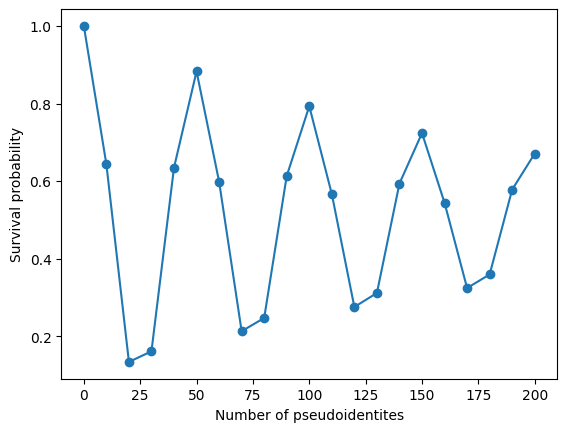

In [9]:
plt.scatter(m_array, all_prob_0)
plt.plot(m_array, all_prob_0)
plt.xlabel(f"Number of pseudoidentites")
plt.ylabel(f"Survival probability")
plt.show()

# Evaluate whether error is an over or an under rotation

The probablity $p_0$ crosses the mean point of the first oscillation at approximately $m_{eq} = 12$.

The gate being tested corresponds to a rotation about the $x$ axis and the initial state corresponds to the $+z$ axis. $\vec{\phi} = \vec{x} \times \vec{z} = -\vec{y}$, thus $\ket{\phi} = \ket{L}$.

The unitary $U_\phi$ is $Rx(\pi/2)$. Therefore, the gate we need to apply, $U_\phi^\dagger$ is $Rx(-\pi/2)$.

In [10]:
num_gates_for_id = 4
m_eq = 12
qc = qiskit.QuantumCircuit(1,1)
# Qubit already prepared in |0> state

# Repeat pseudoidentity m_eq times
for _ in range(m_eq):
    # Pseudoidentity formed by repeating sx gate 4 times
    for _ in range(num_gates_for_id):
        qc.sx(0)

# Apply Rx(-\pi/2)
qc.rx(-np.pi/2,0)

# Measure qubit (state preparation step inversion not needed)
qc.measure(0,0)

submitter.submit_circuits(
    shots=num_shots,
    qasm_strs=[qc.qasm()],
    skip_asking=True,
    skip_transpilation=True,
)
counts = submitter.retrieve_counts()[0]

if '0' in counts.keys():
    prob_phi = counts['0'] / num_shots
else:
    prob_phi = num_shots - counts['1'] / num_shots
print(f"{prob_phi=}")
if prob_phi > 0.5:
    print(f"prob_phi > 0.5, thus, the error corresponds to an overrotation")
else:
    print(f"prob_phi < 0.5, thus, the error corresponds to an underrotation")


Ready to run 1 circuits on noisy_sim with 1024 shots.
Cost: 1 * ($0 + 1024 * $0) = $0.00.
Circuits have been submitted
2025-02-11 16:52:54 All circuits are finished
prob_phi=0.96875
prob_phi > 0.5, thus, the error corresponds to an overrotation


# Fit results to calculate metric

Calculated error magnitude was 0.01pi


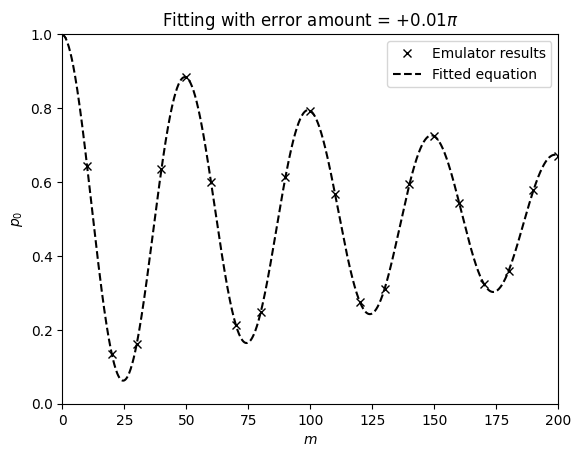

In [12]:
def fit_func(m, a, b, decay_rate, theta_err):
    return 0.5 + a + 0.5*(1-b)*np.exp(-1*decay_rate*m)*np.cos(m*theta_err)

popt, pcov = curve_fit(fit_func, m_array, all_prob_0, p0=[0,0,0,0.0001])
fit_overrotation_amount = np.absolute(popt[3]/num_gates_for_id) # Divide by 2 because each pseudoidentity is comprised of 2 X gates
print(f"Calculated error magnitude was {np.round(fit_overrotation_amount/np.pi, 3)}pi")

plt.figure()
plt.plot(m_array, all_prob_0, linestyle="", marker="x", c='black', label="Emulator results")
fit_xxs =  np.linspace(0,m_max+1, 1000)
plt.plot(fit_xxs, fit_func(fit_xxs, *popt), linestyle="--", marker="", c='black', label="Fitted equation")
plt.xlim((0, m_max))
plt.ylim((0, 1))
plt.xlabel(r"$m$")
plt.ylabel(r"$p_0$")

overrotation_sign = "+" if prob_phi > 0.5 else "-"

plt.title(fr"Fitting with error amount = {overrotation_sign}{np.round(fit_overrotation_amount/np.pi, 3)}$\pi$")
plt.legend()
plt.show()



# Run on hardware

In [13]:
import sys
import pathlib
import os
# Relative path to _helpers
sys.path.insert(0, str(pathlib.Path(os.path.abspath('')).parent.parent.parent.resolve()))
from _helpers.circuit_submitter import CircuitSubmitter

In [16]:
all_prob_0 = []
qcs = []
delta_m = 20 # spacing number of repetitions of pseudoidentity formed by repeating G
m_max = 200
num_shots = 500
device_name = "noisy_sim" #Replace with hardware backend

m_array = np.arange(0,m_max+1, delta_m)

for m in m_array:
    qc = qiskit.QuantumCircuit(1,1)
    qc.id(0)
    for _ in range(m):
        qc.sx(0)
        qc.sx(0)
    qcs.append(qc.qasm())

submitter = CircuitSubmitter("over_under_rotations", device_name)
# Uncomment the following lines if you are using a noisy simulator and would like to change the noise model
# noise_model = noise_model
# submitter.backend.device.set_noise_model(noise_model=noise_model)
tasks = submitter.submit_circuits(num_shots, qasm_strs=qcs, skip_transpilation=True)
all_counts = submitter.retrieve_counts(wait=True)

for counts in all_counts:
    if '0' in counts.keys():
        all_prob_0.append(counts['0'] / num_shots)
    else:
        all_prob_0.append(num_shots - counts['1'] / num_shots)

print(all_prob_0)

Ready to run 11 circuits on noisy_sim with 500 shots.
Cost: 11 * ($0 + 500 * $0) = $0.00.
Submitting circuits...
Circuits have been submitted
2025-02-11 16:54:09 All circuits are finished
[1.0, 0.644, 0.134, 0.16, 0.636, 0.884, 0.598, 0.212, 0.246, 0.614, 0.794]


Benchmarking over or under rotation of X gate with delta_m=20, m_max=200

all_prob_0=[1.0, 0.644, 0.134, 0.16, 0.636, 0.884, 0.598, 0.212, 0.246, 0.614, 0.794]

Calculated overrotation is 0.01 pi


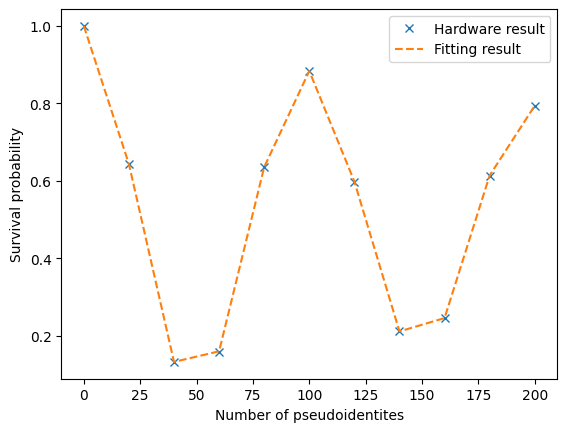

In [15]:
popt, pcov = curve_fit(fit_func, m_array, all_prob_0,p0=[0,0,0,0.0001])
fit_overrotation_amount = np.absolute(popt[3]/2) # Divide by 2 because each pseudoidentity is comprised of 2 X gates
result_str = f"""Benchmarking over or under rotation of X gate with delta_m={delta_m}, m_max={m_max}\n
all_prob_0={all_prob_0}\n
Calculated overrotation is {np.round(fit_overrotation_amount/np.pi, 3)} pi"""
print(result_str)
with open(submitter.benchmark_path + "/result_device.txt", "w+") as f:
    f.write(result_str)

plt.figure()
plt.plot(m_array, all_prob_0, linestyle="", marker="x", label="Hardware result")
plt.plot(m_array, fit_func(m_array, *popt), linestyle="--", marker="", label="Fitting result")
plt.xlabel(f"Number of pseudoidentites")
plt.ylabel(f"Survival probability")
plt.legend()
plt.savefig(submitter.benchmark_path + "/plot_device.png", format="png")
plt.show()